# Spam Email Detection

## 02. Exploratory Data Analysis (EDA)

EDA is performed to understand message length, word count, class distribution, text patterns, and relationships between derived numerical features.

In [2]:
## output

from pathlib import Path

# Project root
BASE_DIR = Path.cwd().parent.parent

# Dataset
DATA_DIR = BASE_DIR / "data"

# Outputs
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "results"

# Models
MODEL_DIR = BASE_DIR / "models"

# Create folders
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "email.csv"

print("PROJECT:", BASE_DIR)
print("DATASET:", DATA_PATH)
print("FIGURES:", FIGURE_DIR)
print("RESULTS:", RESULT_DIR)
print("MODELS:", MODEL_DIR)

PROJECT: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection
DATASET: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\data\email.csv
FIGURES: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\outputs\figures
RESULTS: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\outputs\results
MODELS: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\models


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

BASE_DIR = Path.cwd().parent.parent

DATA_PATH = BASE_DIR / "data" / "email.csv"

OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "results"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

df["Category"] = df["Category"].astype(str).str.strip().str.lower()

df = df[
    df["Category"].isin(["ham", "spam"])
].copy()

df["Message"] = df["Message"].astype(str)

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape:", df.shape)

Dataset shape: (5157, 2)


In [4]:
# ============================================================
# TEXT FEATURES
# ============================================================

df["character_count"] = df["Message"].str.len()

df["word_count"] = (
    df["Message"]
    .str.split()
    .str.len()
)

df["sentence_count"] = (
    df["Message"]
    .str.count(r"[.!?]")
)

df[[
    "character_count",
    "word_count",
    "sentence_count"
]].describe()

,character_count,word_count,sentence_count
count,5157.000000,5157.000000,5157.000000
mean,79.103936,15.410704,2.489044
std,58.382922,11.118902,2.721229
min,2.000000,1.000000,0.000000
25%,36.000000,7.000000,1.000000
50%,61.000000,12.000000,2.000000
75%,118.000000,22.000000,3.000000
max,910.000000,171.000000,42.000000


In [5]:
df[
    ["character_count", "word_count", "sentence_count"]
].describe().to_csv(
    RESULT_DIR / "08_descriptive_statistics.csv"
)

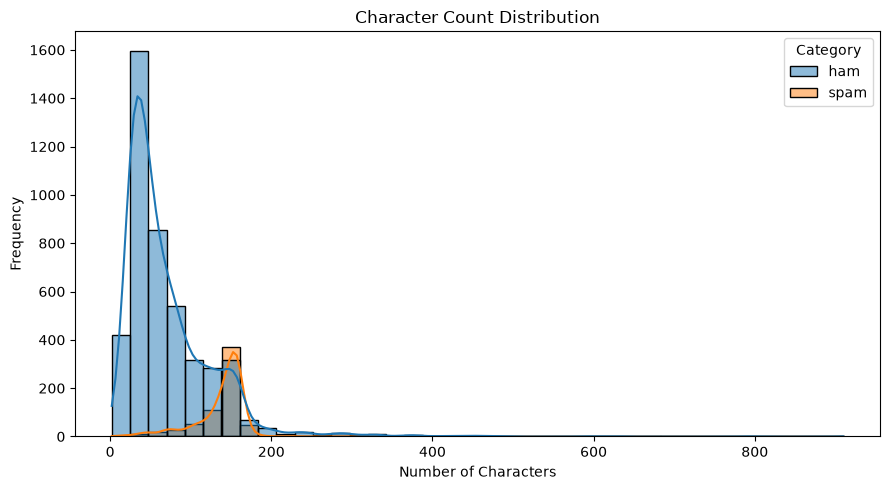

In [6]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="character_count",
    hue="Category",
    bins=40,
    kde=True
)

plt.title("Character Count Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "02_character_count_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

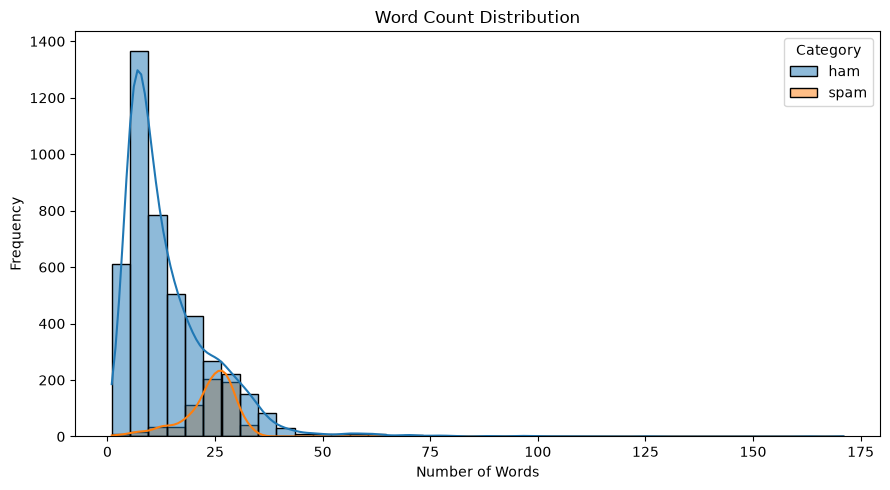

In [7]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="word_count",
    hue="Category",
    bins=40,
    kde=True
)

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "03_word_count_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

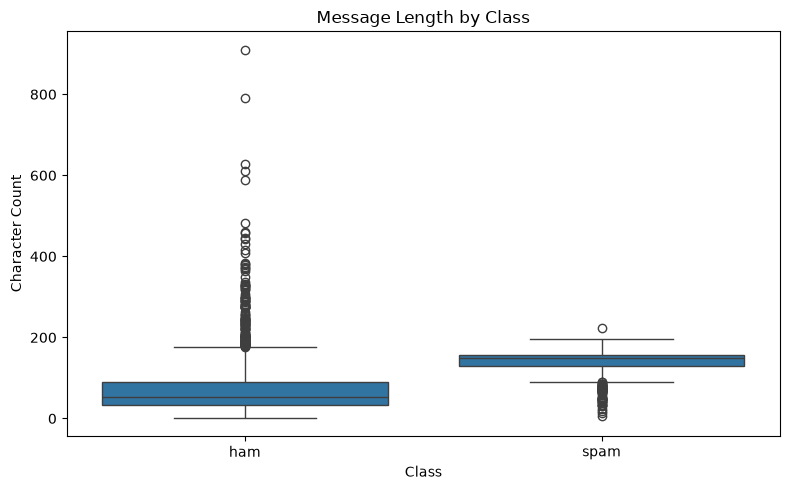

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Category",
    y="character_count"
)

plt.title("Message Length by Class")
plt.xlabel("Class")
plt.ylabel("Character Count")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "04_message_length_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

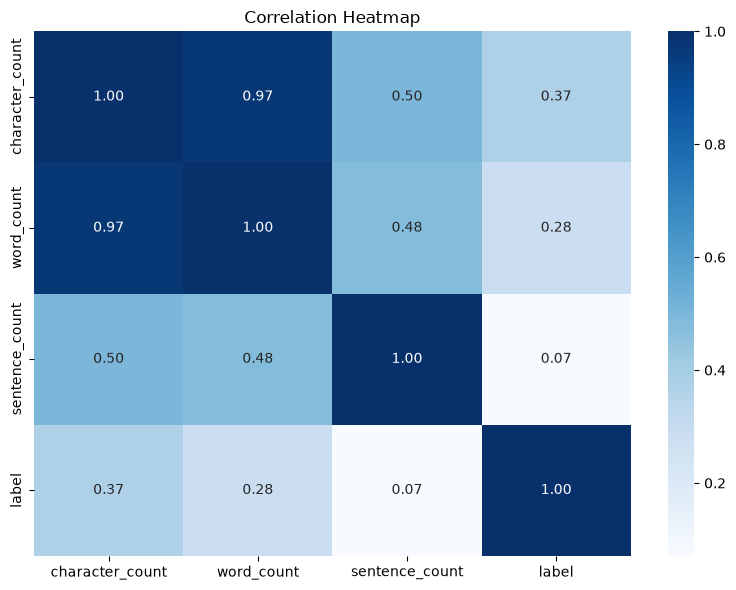

In [9]:
numeric_features = [
    "character_count",
    "word_count",
    "sentence_count"
]

df["label"] = df["Category"].map({
    "ham": 0,
    "spam": 1
})

corr = df[
    numeric_features + ["label"]
].corr()

corr.to_csv(
    RESULT_DIR / "09_correlation_matrix.csv"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "05_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
df.to_csv(
    RESULT_DIR / "eda_text_features.csv",
    index=False
)

print("EDA results saved successfully!")

EDA results saved successfully!
